### Importar librerías

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar datos

In [2]:
file_path = Path("../data/processed/dataset_clean.csv")
df = pd.read_csv(file_path)

df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S


### Revisar estructura

In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    str    
 4   sex          891 non-null    str    
 5   age          891 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    str    
 9   fare         891 non-null    float64
 10  cabin        891 non-null    str    
 11  embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
passengerid,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,891.0,NaN,NaN,NaN,29.361582,13.019697,0.42,22.0,28.0,35.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### Revisar valores nulos

In [6]:
nulls = df.isna().sum().sort_values(ascending=False)
nulls[nulls > 0]

Series([], dtype: int64)

### Analizar variables numéricas

In [7]:
numeric_df = df.select_dtypes(include="number")
numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
passengerid,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


### Crear histogramas

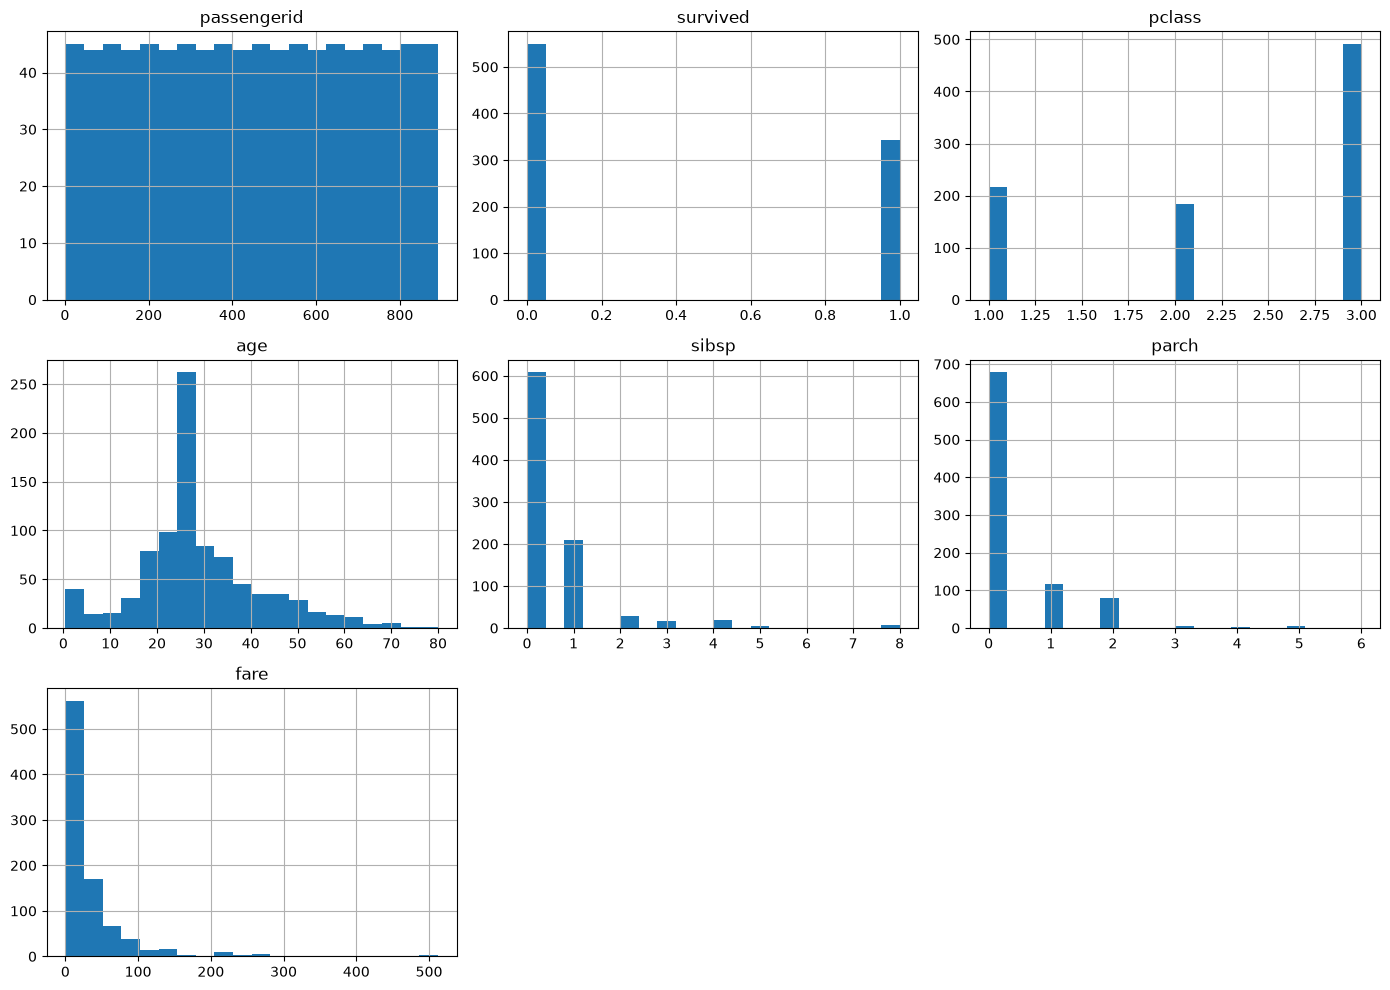

In [8]:
numeric_df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

### Crear diagramas de caja

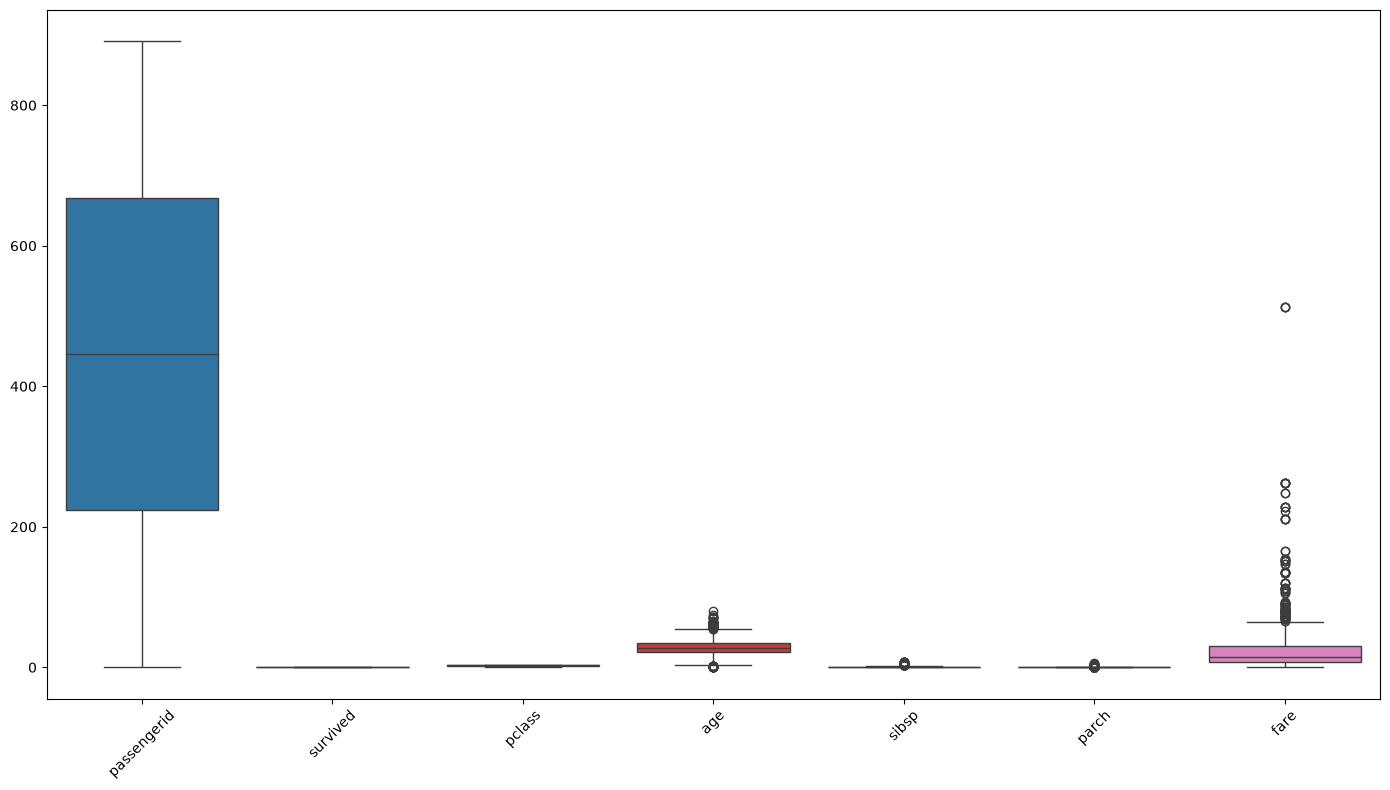

In [9]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=numeric_df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Crear matriz de correlación

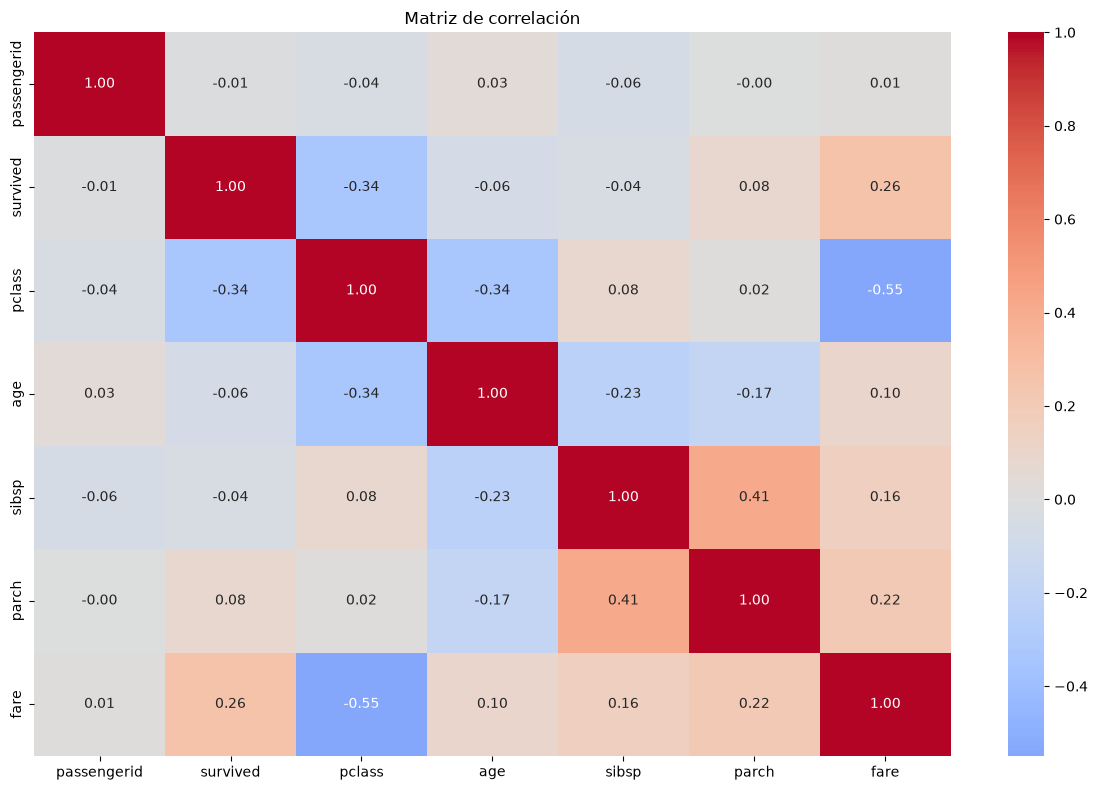

In [10]:
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Extraer correlaciones importantes

In [11]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

strong_correlations = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "variable_1",
        "level_1": "variable_2",
        0: "correlation"
    })
)

strong_correlations["absolute_correlation"] = (
    strong_correlations["correlation"].abs()
)

strong_correlations.sort_values(
    "absolute_correlation",
    ascending=False
).head(10)

,variable_1,variable_2,correlation,absolute_correlation
20,pclass,fare,-0.549500,0.549500
33,sibsp,parch,0.414838,0.414838
17,pclass,age,-0.339898,0.339898
9,survived,pclass,-0.338481,0.338481
13,survived,fare,0.257307,0.257307
25,age,sibsp,-0.233296,0.233296
41,parch,fare,0.216225,0.216225
26,age,parch,-0.172482,0.172482
34,sibsp,fare,0.159651,0.159651
27,age,fare,0.096688,0.096688


### Crear un gráfico de dispersión

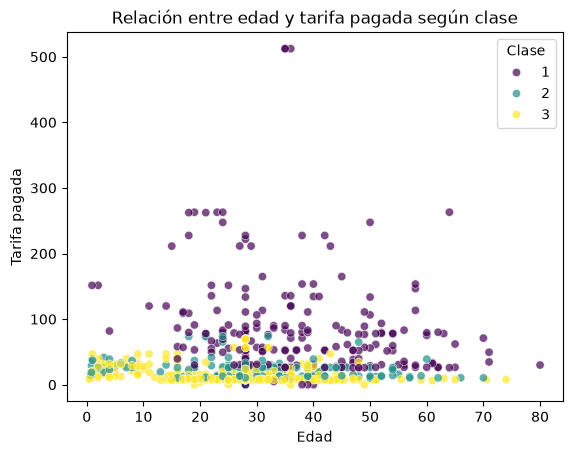

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="pclass",
    palette="viridis",
    alpha=0.7
)

plt.title("Relación entre edad y tarifa pagada según clase")
plt.xlabel("Edad")
plt.ylabel("Tarifa pagada")
plt.legend(title="Clase")
plt.show()